
# Lab1_3: PDE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



#### **Exercise 1**: Lab1_3: finite-differences with tolerance **Jacobi method**


SOlve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
2. Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

#### **Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

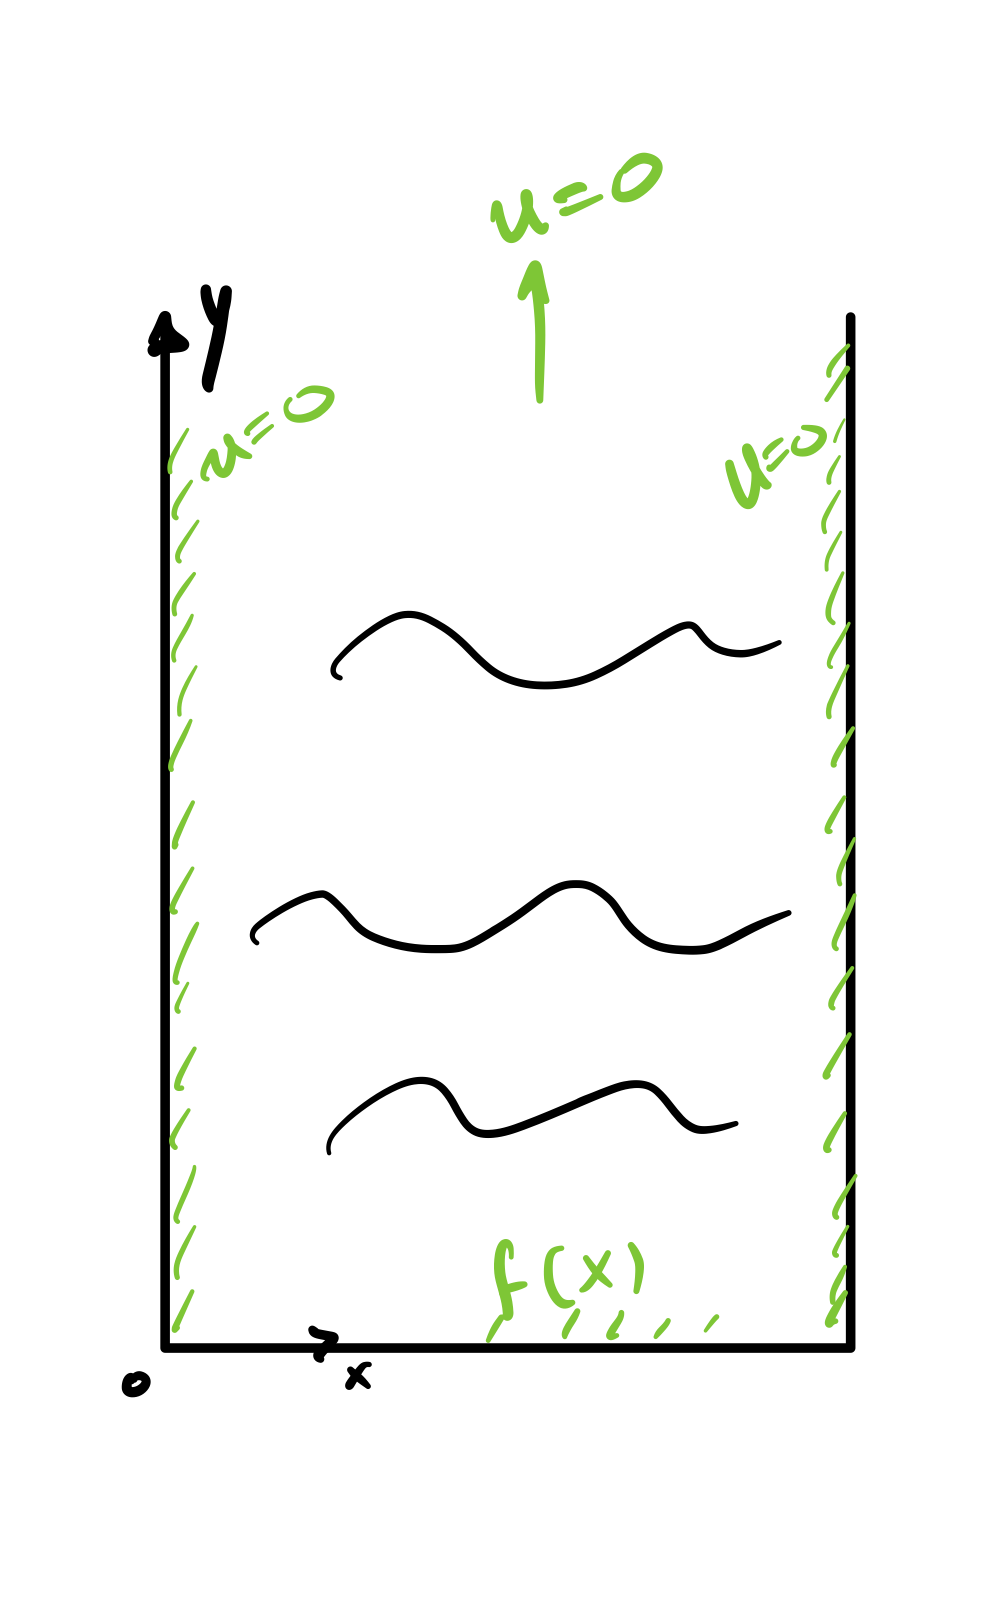

In [ ]:
from IPython.display import Image
Image(filename=path+filename4, width=300)

# Solución - Ejercicio 1

=== Sin Numba ===
Iteraciones: 6073
Error final: 9.996262e-04
Tiempo: 72.870822 s

=== Con Numba ===
Iteraciones: 6073
Error final: 9.996262e-04
Tiempo: 0.180462 s

=== Comparación ===
Max |V_py - V_nb| = 0.000000e+00


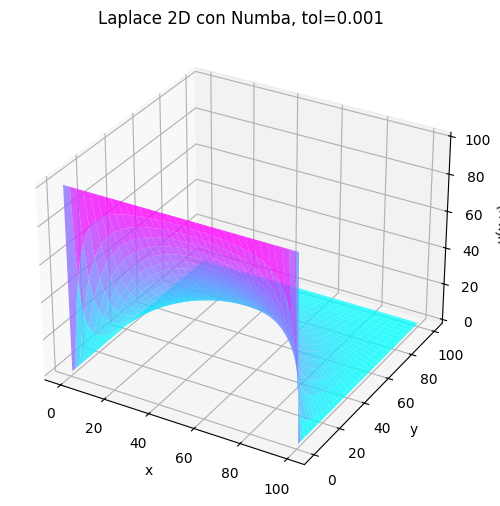

In [8]:
# @title
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# --------------------------
# Jacobi en Python puro
# --------------------------
def Laplace2D_tolerance_py(V_ini, tolerance):
    Nmax = V_ini.shape[0]
    V_old = V_ini.copy()
    V_new = V_ini.copy()

    max_diff = float('inf')
    iteration_count = 0

    while max_diff > tolerance:
        V_old = V_new.copy()

        for i in range(1, Nmax - 1):
            for j in range(1, Nmax - 1):
                # Método de Jacobi (promedio de vecinos)
                V_new[i, j] = 0.25 * (
                    V_old[i+1, j] + V_old[i-1, j] +
                    V_old[i, j+1] + V_old[i, j-1]
                )

        max_diff = np.max(np.abs(V_new - V_old))
        iteration_count += 1

    return V_new, iteration_count, max_diff


# --------------------------
# Jacobi con Numba
# --------------------------
@njit(cache=True)
def Laplace2D_tolerance_numba(V_ini, tolerance):
    Nmax = V_ini.shape[0]
    V_old = V_ini.copy()
    V_new = V_ini.copy()

    max_diff = 1e20
    iteration_count = 0

    while max_diff > tolerance:
        V_old[:, :] = V_new

        for i in range(1, Nmax - 1):
            for j in range(1, Nmax - 1):
                # Método de Jacobi (promedio de vecinos)
                V_new[i, j] = 0.25 * (
                    V_old[i+1, j] + V_old[i-1, j] +
                    V_old[i, j+1] + V_old[i, j-1]
                )

        max_diff = 0.0
        for i in range(Nmax):
            for j in range(Nmax):
                diff = abs(V_new[i, j] - V_old[i, j])
                if diff > max_diff:
                    max_diff = diff

        iteration_count += 1

    return V_new, iteration_count, max_diff


# --------------------------
# Parámetros del problema
# --------------------------
Nmax = 101
tol = 1e-3

V_ini = np.zeros((Nmax, Nmax))
V_ini[0, :] = 100.0  # u(x,0)=100

# --------------------------
# Medición sin Numba
# --------------------------
inicio = time.perf_counter()
V_py, it_py, err_py = Laplace2D_tolerance_py(V_ini, tol)
fin = time.perf_counter()

print("=== Sin Numba ===")
print(f"Iteraciones: {it_py}")
print(f"Error final: {err_py:.6e}")
print(f"Tiempo: {fin - inicio:.6f} s\n")

# --------------------------
# Warm-up de Numba
# --------------------------
_ = Laplace2D_tolerance_numba(V_ini, tol)

# --------------------------
# Medición con Numba
# --------------------------
inicio = time.perf_counter()
V_nb, it_nb, err_nb = Laplace2D_tolerance_numba(V_ini, tol)
fin = time.perf_counter()

print("=== Con Numba ===")
print(f"Iteraciones: {it_nb}")
print(f"Error final: {err_nb:.6e}")
print(f"Tiempo: {fin - inicio:.6f} s\n")

# --------------------------
# Comparación de resultados
# --------------------------
print("=== Comparación ===")
print(f"Max |V_py - V_nb| = {np.max(np.abs(V_py - V_nb)):.6e}")

# --------------------------
# Gráfica de la solución numérica (puedes dejar solo una)
# --------------------------
x = np.arange(Nmax)
y = np.arange(Nmax)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, V_nb, cmap='cool', alpha=0.8)

ax.set_title(f'Laplace 2D con Numba, tol={tol}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y)')

plt.show()

Calculando serie de Fourier con tolerancia = 0.001
Serie terminada en 20000 términos (n máximo = 39999)
Diferencia máxima alcanzada = 0.003183
Tiempo de ejecución = 12.377678 s


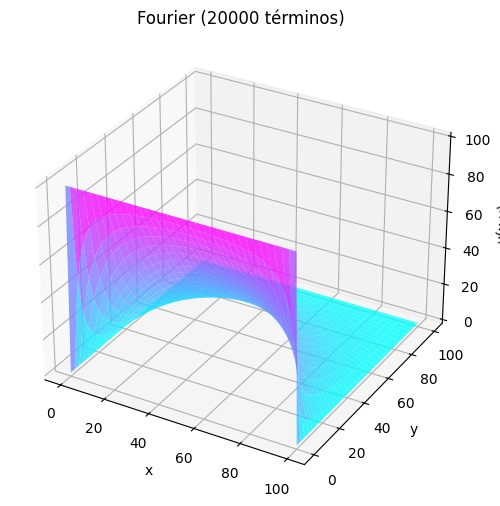

In [9]:
# @title
import time
import numpy as np
import matplotlib.pyplot as plt

#Definir el n-ésimo modo
def un(x,y,n=1,L=1):
  'función para calcular el n-ésimo término de la serie de Fourier'
  v0 = 100 #Voltaje

  x_arr = np.asarray(x)
  y_arr = np.asarray(y)

  arg_numerator = n * np.pi * (L - y_arr) / L
  arg_denominator = n * np.pi

  threshold = np.log(np.finfo(float).max) - 10

  if arg_denominator > threshold:
      ratio_sinh = np.exp(-n * np.pi * y_arr / L)
  else:
      ratio_sinh = np.sinh(arg_numerator) / np.sinh(arg_denominator)

  return (4 * v0 / (n * np.pi)) * np.sin(n * np.pi * x_arr / L) * ratio_sinh


# --- Parámetros ---
L = 100
tol_fourier = 1e-3

x_coords = np.arange(0, L + 1, 1)
y_coords = np.arange(0, L + 1, 1)

X_grid, Y_grid = np.meshgrid(x_coords, y_coords)

z = np.zeros_like(X_grid, dtype=float)

max_diff_fourier = float('inf')
current_n = 1
n_terms = 0
N_max_fourier_terms_limit = 20000

print(f"Calculando serie de Fourier con tolerancia = {tol_fourier}")

# Medir tiempo
inicio = time.perf_counter()

while max_diff_fourier > tol_fourier and n_terms < N_max_fourier_terms_limit:
  z_old = z.copy()

  term_n = un(X_grid, Y_grid, n=current_n, L=L)
  z += term_n

  valid_diff = np.abs(z - z_old)

  if np.any(np.isnan(valid_diff)):
      max_diff_fourier = float('inf')
  else:
      max_diff_fourier = np.max(valid_diff)

  current_n += 2
  n_terms += 1

fin = time.perf_counter()

print(f"Serie terminada en {n_terms} términos (n máximo = {current_n-2})")
print(f"Diferencia máxima alcanzada = {max_diff_fourier:.6f}")
print(f"Tiempo de ejecución = {fin - inicio:.6f} s")


#Graficar
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X_grid, Y_grid, z, cmap='cool', alpha=0.8)

ax.set_title(f'Fourier ({n_terms} términos)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y)')
plt.show()

## Ejercicio 1 — Laplace equation, Jacobi method and Fourier series

Se resolvió la ecuación de Laplace en el dominio cuadrado $0 \le x \le L$, $0 \le y \le L$ con las condiciones de frontera

$$
u(x,0)=100,\qquad u(0,y)=0,\qquad u(L,y)=0,\qquad u(x,L)=0.
$$

### 1. Solución por diferencias finitas

Para resolver el problema numéricamente se discretizó el dominio con $\Delta=1$ y $L=100$, y se usó el método de Jacobi. En cada punto interior de la malla se aplicó la regla de promedio entre los cuatro vecinos:

$$
u_{i,j}^{(k+1)}=\frac{1}{4}\left(u_{i+1,j}^{(k)}+u_{i-1,j}^{(k)}+u_{i,j+1}^{(k)}+u_{i,j-1}^{(k)}\right).
$$

La idea fue repetir este proceso hasta que el cambio máximo entre dos iteraciones consecutivas fuera menor que la tolerancia escogida, en este caso $\text{tol}=10^{-3}$. Con esto se obtuvo una solución estable para el potencial en toda la malla.

### 2. Estrategia para hacer la gráfica

Primero se definió una matriz inicial con todos los valores en cero, excepto la frontera inferior, donde se impuso $u(x,0)=100$. Luego se fue actualizando el interior de la malla con el esquema de Jacobi hasta converger. Finalmente, con los valores obtenidos se construyó la superficie $u(x,y)$ y se graficó en 3D.

La forma de la solución tiene sentido físico: el potencial vale $100$ en la base y va disminuyendo al alejarse de esa frontera, mientras que los otros bordes están fijados en cero. Por eso la superficie cae suavemente hacia el interior del dominio.

### 3. Comparación entre Jacobi en Python y Jacobi con Numba

Para mejorar el tiempo de ejecución se comparó la implementación normal en Python con otra usando Numba. Ambas dieron exactamente la misma solución numérica, pero el tiempo cambió bastante:

- Jacobi en Python: $72.87\ \text{s}$
- Jacobi con Numba: $0.18\ \text{s}$

Las dos versiones convergieron en $6073$ iteraciones con error final aproximadamente igual a $10^{-3}$, y la diferencia máxima entre ambas soluciones fue

$$
\max |u_{\text{Python}}-u_{\text{Numba}}|=0.
$$

Esto muestra que Numba no cambia el resultado, solo acelera mucho el cálculo. En este problema vale la pena usarlo porque el cuello de botella está en los dos ciclos anidados del método de Jacobi, y Numba los vuelve mucho más rápidos.

### 4. Comparación con la serie de Fourier

La solución analítica en serie de Fourier para este problema es

$$
u(x,y)=\sum_{\substack{n=1 \\ n\ \text{impar}}}^{\infty}
\frac{4V_0}{n\pi}\sin\left(\frac{n\pi x}{L}\right)
\frac{\sinh\left(\frac{n\pi(L-y)}{L}\right)}{\sinh(n\pi)}.
$$

Se evaluó la serie sumando términos impares hasta que el aporte del último término fuera menor que la tolerancia de $10^{-3}$. Con ese criterio se obtuvieron:

- $20000$ términos
- diferencia máxima alcanzada: $3.183\times 10^{-3}$
- tiempo de ejecución: $12.38\ \text{s}$

Con el criterio usado en el código, la serie no alcanzó estrictamente la tolerancia antes de llegar al límite máximo de términos. Aun así, la gráfica ya muestra una solución estable y con la forma esperada. Esto indica que el criterio de parada fue bastante exigente, porque evaluaba el peor cambio puntual en toda la malla.

### Conclusión

El método de Jacobi resuelve bien la ecuación de Laplace, pero en Python puro resulta lento. Con Numba, el tiempo de cómputo baja muchísimo sin cambiar la solución. La serie de Fourier también describe correctamente el problema, pero con el criterio usado necesitó muchos términos para acercarse a la tolerancia pedida.

En resumen, para este ejercicio se obtiene la misma física por dos caminos distintos: el método numérico por diferencias finitas y la solución analítica por serie de Fourier. Numba hace que la parte numérica sea mucho más eficiente.

# Solución - Ejercicio 2

=== Solución analítica ===
Tiempo: 0.000749 s

=== Jacobi sin Numba ===
Iteraciones: 2359
Error final: 9.992270e-04
Tiempo: 28.737750 s

=== Jacobi con Numba ===
Iteraciones: 2359
Error final: 9.992270e-04
Tiempo: 0.069925 s

=== Comparaciones ===
Max |V_py - V_nb| = 0.000000e+00
Max |V_nb - U_exact| = 7.410171e-01


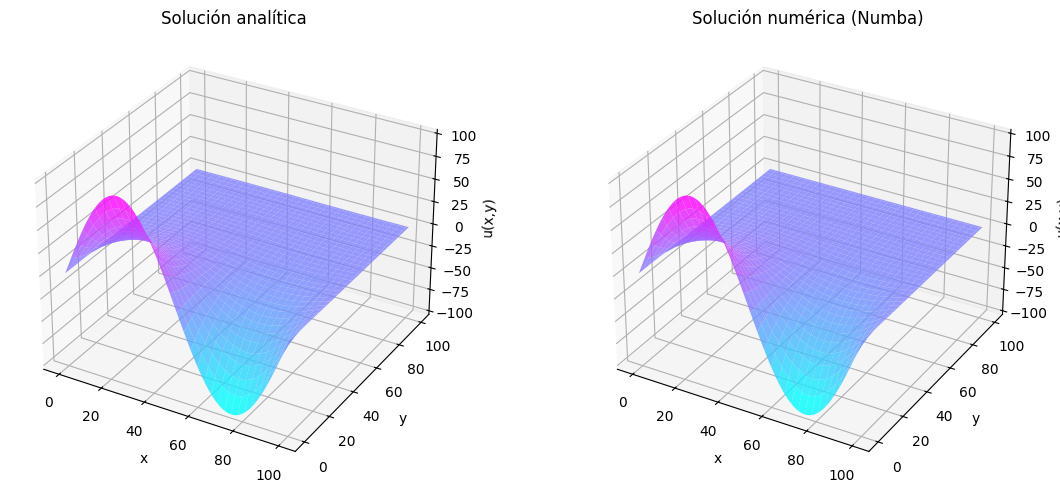

In [10]:
# @title
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# --------------------------
# Parámetros del problema
# --------------------------
L = 100
u0 = 100
tol = 1e-3

# Para aproximar y -> infinito se trunca el dominio en y = L
# y se usa Δ = 1, así que conviene tener 101 nodos: 0, 1, ..., 100
Nx = 101
Ny = 101

x = np.linspace(0, L, Nx)
y = np.linspace(0, L, Ny)
X, Y = np.meshgrid(x, y)

# --------------------------
# Solución analítica
# --------------------------
inicio = time.perf_counter()
U_exact = u0 * np.sin(2 * np.pi * X / L) * np.exp(-2 * np.pi * Y / L)
fin = time.perf_counter()
print("=== Solución analítica ===")
print(f"Tiempo: {fin - inicio:.6f} s\n")

# --------------------------
# Condición inicial para Jacobi
# --------------------------
V_ini = np.zeros((Ny, Nx))
V_ini[0, :] = u0 * np.sin(2 * np.pi * x / L)

# --------------------------
# Jacobi en Python puro
# --------------------------
def Laplace_open_py(V_ini, tol):
    V_new = V_ini.copy()
    V_old = V_ini.copy()

    Ny, Nx = V_ini.shape
    diff = float('inf')
    iteration_count = 0

    while diff > tol:
        V_old = V_new.copy()

        for i in range(1, Ny - 1):
            for j in range(1, Nx - 1):
                V_new[i, j] = 0.25 * (
                    V_old[i + 1, j] + V_old[i - 1, j] +
                    V_old[i, j + 1] + V_old[i, j - 1]
                )

        diff = np.max(np.abs(V_new - V_old))
        iteration_count += 1

    return V_new, iteration_count, diff

# --------------------------
# Jacobi con Numba
# --------------------------
@njit(cache=True)
def Laplace_open_numba(V_ini, tol):
    V_new = V_ini.copy()
    V_old = V_ini.copy()

    Ny, Nx = V_ini.shape
    diff = 1e20
    iteration_count = 0

    while diff > tol:
        V_old[:, :] = V_new

        for i in range(1, Ny - 1):
            for j in range(1, Nx - 1):
                V_new[i, j] = 0.25 * (
                    V_old[i + 1, j] + V_old[i - 1, j] +
                    V_old[i, j + 1] + V_old[i, j - 1]
                )

        diff = 0.0
        for i in range(Ny):
            for j in range(Nx):
                d = abs(V_new[i, j] - V_old[i, j])
                if d > diff:
                    diff = d

        iteration_count += 1

    return V_new, iteration_count, diff

# --------------------------
# Medición sin Numba
# --------------------------
inicio = time.perf_counter()
V_py, it_py, err_py = Laplace_open_py(V_ini, tol)
fin = time.perf_counter()

print("=== Jacobi sin Numba ===")
print(f"Iteraciones: {it_py}")
print(f"Error final: {err_py:.6e}")
print(f"Tiempo: {fin - inicio:.6f} s\n")

# --------------------------
# Warm-up de Numba
# --------------------------
_ = Laplace_open_numba(V_ini, tol)

# --------------------------
# Medición con Numba
# --------------------------
inicio = time.perf_counter()
V_nb, it_nb, err_nb = Laplace_open_numba(V_ini, tol)
fin = time.perf_counter()

print("=== Jacobi con Numba ===")
print(f"Iteraciones: {it_nb}")
print(f"Error final: {err_nb:.6e}")
print(f"Tiempo: {fin - inicio:.6f} s\n")

# --------------------------
# Comparaciones
# --------------------------
print("=== Comparaciones ===")
print(f"Max |V_py - V_nb| = {np.max(np.abs(V_py - V_nb)):.6e}")
print(f"Max |V_nb - U_exact| = {np.max(np.abs(V_nb - U_exact)):.6e}")

# --------------------------
# Gráficas
# --------------------------
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, U_exact, cmap='cool', alpha=0.8)
ax1.set_title('Solución analítica')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('u(x,y)')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, V_nb, cmap='cool', alpha=0.8)
ax2.set_title('Solución numérica (Numba)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u(x,y)')

plt.tight_layout()
plt.show()

## Ejercicio 2 — Laplace equation with open boundary

Se resolvió la ecuación de Laplace en el dominio $0 \le x \le L$, $0 \le y < \infty$ con condiciones de frontera:

- $u(x,0)=u_0\sin\left(\frac{2\pi x}{L}\right)$
- $u(0,y)=0$
- $u(L,y)=0$
- $u(x,\infty)=0$

Para resolver el problema numéricamente se truncó el dominio en $y=L$, lo cual es válido porque la solución decae exponencialmente en la dirección $y$.

---

### Solución analítica

La solución exacta del problema es:

$$
u(x,y)=u_0\sin\left(\frac{2\pi x}{L}\right)e^{-2\pi y/L}
$$

Esta se evaluó directamente usando operaciones vectorizadas de NumPy.

- Tiempo de ejecución: **0.00075 s**

Esto muestra que la solución analítica es extremadamente eficiente cuando se conoce la forma exacta.

---

### Solución numérica (método de Jacobi)

Se resolvió el problema usando diferencias finitas con el método de Jacobi, aplicando la condición de frontera en $y=0$ y dejando que el método relaje el interior del dominio.

Se utilizó una tolerancia de $10^{-3}$.

#### Resultados

- Iteraciones: **2359**
- Error final: $\sim 10^{-3}$

#### Tiempos de ejecución

| Método            | Tiempo (s) |
|------------------|------------|
| Jacobi (Python)  | 28.74      |
| Jacobi (Numba)   | 0.07       |

Ambas implementaciones producen exactamente el mismo resultado numérico:

$$
\max |u_{\text{Python}} - u_{\text{Numba}}| = 0
$$

---

### Comparación con la solución analítica

Se comparó la solución numérica con la solución exacta, obteniendo:

$$
\max |u_{\text{num}} - u_{\text{exact}}| \approx 0.74
$$

Este valor relativamente alto se debe a que el dominio infinito en $y$ fue truncado en $y=L$. Aunque la solución analítica decae exponencialmente, el truncamiento introduce un error, especialmente en regiones donde la solución aún no es completamente despreciable.

---

### Discusión

- La solución analítica es la más eficiente en términos computacionales, ya que solo requiere evaluar una expresión cerrada.
- El método de Jacobi es más general, pero requiere muchas iteraciones para converger.
- El uso de Numba reduce el tiempo de ejecución en más de dos órdenes de magnitud, lo que hace que el método numérico sea mucho más viable.

---

### Conclusión

- Cuando la solución analítica es conocida, esta es claramente la mejor opción en términos de eficiencia.
- El método numérico permite resolver el problema incluso cuando no se conoce la solución exacta, pero es más costoso computacionalmente.
- Numba mejora significativamente el rendimiento del método de Jacobi sin afectar la precisión.
- El truncamiento del dominio infinito introduce un error adicional que debe tenerse en cuenta en la interpretación de los resultados.